In [1]:
import numpy as np
import pandas as pd
import os
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling import models, fitting
import matplotlib.pyplot as plt
from astroquery.simbad import Simbad
from netCDF4 import Dataset
from astropy.visualization import simple_norm

In [2]:
def locate_pointsource(map,x0_f,y0_f,vis=False):
    x0_f, y0_f = int(np.round(x0_f)), int(np.round(y0_f))
    map = map[y0_f-20:y0_f+20,x0_f-20:x0_f+20]
    amp = np.max(map) - 200
    y0, x0 = np.unravel_index(map.argmax(), map.shape)
    gauss = models.Gaussian2D(amplitude=amp, x_mean=x0, y_mean=y0, 
                              x_stddev=5, y_stddev=5, theta=0) + models.Const2D(amplitude=200)
    gauss.y_stddev_0.tied = lambda model: model.x_stddev_0
    fitter = fitting.LevMarLSQFitter(calc_uncertainties=True)
    yi, xi = np.indices(map.shape)
    fit_func = fitter(gauss, xi, yi, map)
    x = fit_func.x_mean_0 + x0_f - 20
    y = fit_func.y_mean_0 + y0_f - 20
    if vis:
        print(fit_func)
        plt.imshow(map,origin='lower')
        plt.axvline(20,c='orange',label='Real Location')
        plt.axhline(20,c='orange')
        plt.axvline(fit_func.x_mean_0.value,c='blue',label='Fit Location')
        plt.axhline(fit_func.y_mean_0.value,c='blue')
        plt.legend()
        plt.show()
    return (x, y)

In [3]:
def rot_a(angle):
    m = np.eye(2)
    m[0,0] = m[1,1] = np.cos(angle)
    m[0,1] = +np.sin(angle)
    m[1,0] = -np.sin(angle)
    return m

In [4]:
path = './testing_files_3/redu00/'#../pointing_maps/cleaned_maps/'#'./testing_files/'#'../pointing_maps/cleaned_maps/'
obs_names = [131947,131949,134710,134712,134714,134859,134861]
simbad_results = Simbad.query_object('VLA 1623')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
nc_files = os.listdir('./nc_files')
for obs in obs_names:
    print(obs)
    path_obj = path + str(obs) + '/raw/'
    fits_file_ = fits.open(path_obj + f'toltec_commissioning_a1100_science_{str(obs)}_citlali.fits')
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    nc_file_path = [file for file in nc_files if str(obs) in file][0]
    nc_file = Dataset('./nc_files/' + nc_file_path)
    Tel_PA = nc_file.variables['Data.TelescopeBackend.ActParAng'][:].data # in radians
    Tel_PA = np.median(Tel_PA)
    coord_pix = WCS(map_header,naxis=2).world_to_pixel(real_coordinate)
    cut_map = np.clip(map_dat, a_min=200, a_max=1000)
    map_x, map_y = locate_pointsource(cut_map, coord_pix[0], coord_pix[1],vis=False)
    map_coordinate = WCS(map_header,naxis=2).pixel_to_world(map_x, map_y).icrs # in ICRS
    delta_ra = map_coordinate.ra.arcsec - real_coordinate.ra.arcsec
    delta_dec = map_coordinate.dec.arcsec - real_coordinate.dec.arcsec
    delta_az, delta_alt = rot_a(Tel_PA) @ np.array([-delta_ra, delta_dec])
    print('')
    print('RA/DEC:', -delta_ra, -delta_dec)
    print('Az/Alt:', -delta_az, -delta_alt)
    print('')

131947

RA/DEC: -2.4088954253820702 2.8252564768481534
Az/Alt: 2.588306415160761 2.6618642398959333

131949

RA/DEC: -2.004943782230839 2.6663194885186385
Az/Alt: 2.5848844040664143 2.1088935019044026

134710

RA/DEC: 2.67994184512645 -1.0452824066451285
Az/Alt: -2.8273886337827605 -0.5296953053007436

134712

RA/DEC: 2.8816740524489433 1.5524006554624066
Az/Alt: -2.1791966627700954 2.4423544060208187

134714

RA/DEC: -2.0470564452698454 4.522257405289565
Az/Alt: 3.974795144228556 2.973593060799379

134859

RA/DEC: -2.3424419031944126 -2.8870949238480534
Az/Alt: 1.1771289097663047 -3.5265732232498235

134861

RA/DEC: -1.7590264095924795 -2.701351198658813
Az/Alt: 0.19528858303652902 -3.2176597982811668



131947
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=111.2101621, x_mean=19.62675328, y_mean=20.29991702, x_stddev=1.77123177, y_stddev=1.77123177, theta=3.09735831e+11)>

    [1]: <Const2D(amplitude=199.90835705)>
Parameters:
       amplitude_0          x_mean_0     ...      theta_0         amplitude_1    
    ------------------ ----------------- ... ----------------- ------------------
    111.21016210298573 19.62675328107357 ... 309735830769.5257 199.90835705418766


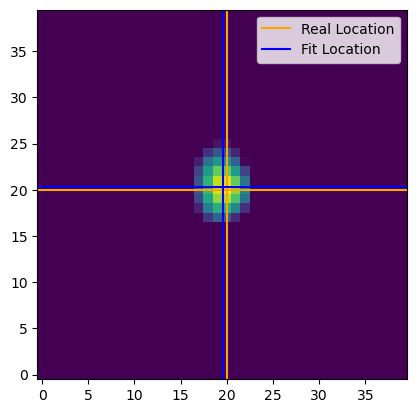

RA/DEC: -0.16738526162225753 -0.2734978693188168
Az/Alt: 0.1491618678401144 -0.2838479302597298

131949
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=78.61210391, x_mean=18.51148289, y_mean=20.65410804, x_stddev=1.80453065, y_stddev=1.80453065, theta=-1.38724819e+12)>

    [1]: <Const2D(amplitude=199.96563077)>
Parameters:
       amplitude_0         x_mean_0     ...      theta_0          amplitude_1    
    ----------------- ----------------- ... ------------------ ------------------
    78.61210390938366 18.51148288669354 ... -1387248191287.161 199.96563077337555


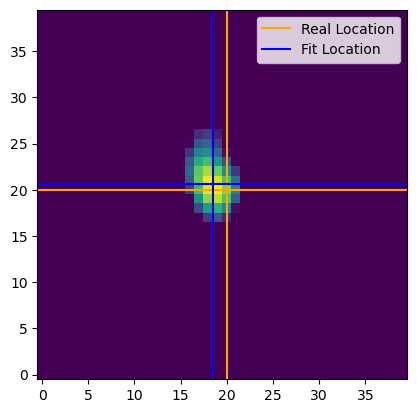

RA/DEC: -1.392128820065409 -0.6276542956329649
Az/Alt: 1.2014200318562913 -0.9426359178058353

134710
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=230.47625732, x_mean=20.09262753, y_mean=19.13918294, x_stddev=2.12929634, y_stddev=2.12929634, theta=-1.72544935e+10)>

    [1]: <Const2D(amplitude=199.69562426)>
Parameters:
       amplitude_0          x_mean_0      ...      theta_0          amplitude_1   
    ------------------ ------------------ ... ------------------ -----------------
    230.47625731735818 20.092627533669635 ... -17254493512.22177 199.6956242570253


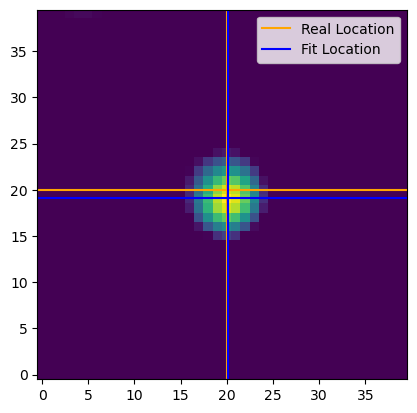

RA/DEC: 0.3442560426192358 0.8872209991532145
Az/Alt: -0.17359707200261998 0.9357015447301573

134712
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=209.77292446, x_mean=19.20511748, y_mean=17.83615541, x_stddev=2.06134401, y_stddev=2.06134401, theta=-4.44039788e+11)>

    [1]: <Const2D(amplitude=199.76581089)>
Parameters:
       amplitude_0          x_mean_0     ...       theta_0          amplitude_1    
    ------------------ ----------------- ... ------------------- ------------------
    209.77292446324083 19.20511747976132 ... -444039787778.45593 199.76581088682505


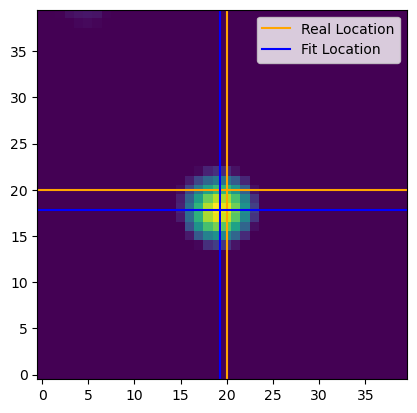

RA/DEC: -0.6303190188482404 2.1902772732864833
Az/Alt: 1.3397193357363255 1.8438461706040716

134714
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=161.61787826, x_mean=15.18601766, y_mean=19.65218296, x_stddev=1.90007355, y_stddev=1.90007355, theta=-1.12404749e+12)>

    [1]: <Const2D(amplitude=199.81499589)>
Parameters:
       amplitude_0          x_mean_0      ...      theta_0          amplitude_1    
    ------------------ ------------------ ... ------------------ ------------------
    161.61787826340532 15.186017660969902 ... -1124047492324.079 199.81499588685918


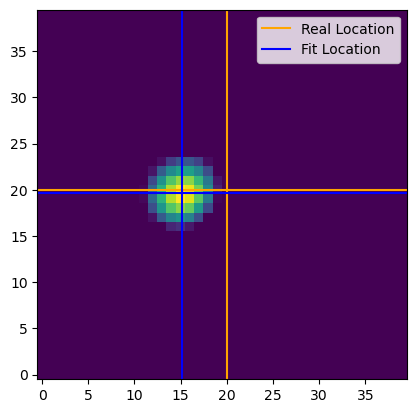

RA/DEC: -5.04395426553674 0.3743578168505337
Az/Alt: 4.598750291578079 -2.1054961799000975

134859
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=345.60628144, x_mean=21.31045327, y_mean=22.26767884, x_stddev=2.20593554, y_stddev=2.20593554, theta=-1.32979939e+10)>

    [1]: <Const2D(amplitude=199.5117392)>
Parameters:
       amplitude_0          x_mean_0      ...       theta_0          amplitude_1    
    ------------------ ------------------ ... ------------------- ------------------
    345.60628143843513 21.310453265524977 ... -13297993906.526865 199.51173919995583


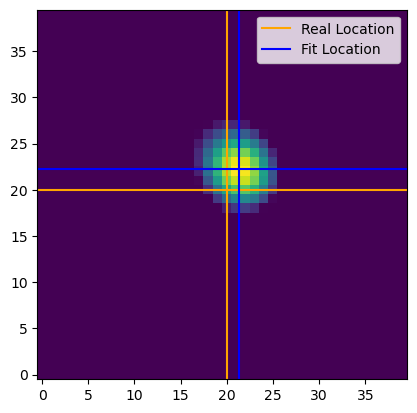

RA/DEC: 1.6814888265216723 -2.2413172463711817
Az/Alt: -2.3624496026967057 -1.506565480593626

134861
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=378.7132515, x_mean=21.39552713, y_mean=22.85679285, x_stddev=2.17625998, y_stddev=2.17625998, theta=4.85344732e+10)>

    [1]: <Const2D(amplitude=199.49340475)>
Parameters:
       amplitude_0         x_mean_0      ...     theta_0        amplitude_1    
    ----------------- ------------------ ... --------------- ------------------
    378.7132514999669 21.395527128994917 ... 48534473185.329 199.49340475409954


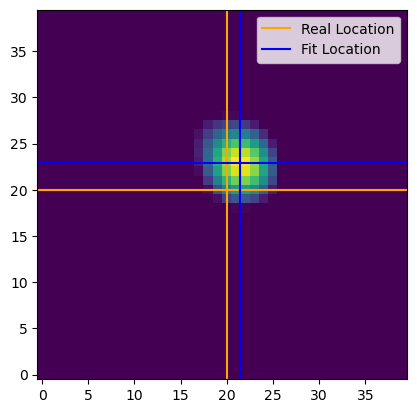

RA/DEC: 1.774888732819818 -2.8304343483468983
Az/Alt: -2.941260553152136 -1.5844794011484848



In [5]:
# computed with CCW rotation offset
path = './testing_files_4/redu01/'#../pointing_maps/cleaned_maps/'#'./testing_files/'#'../pointing_maps/cleaned_maps/'
obs_names = [131947,131949,134710,134712,134714,134859,134861]
simbad_results = Simbad.query_object('VLA 1623')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
nc_files = os.listdir('./nc_files')
for obs in obs_names:
    print(obs)
    path_obj = path + str(obs) + '/raw/'
    fits_file_ = fits.open(path_obj + f'toltec_commissioning_a1100_science_{str(obs)}_citlali.fits')
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    nc_file_path = [file for file in nc_files if str(obs) in file][0]
    nc_file = Dataset('./nc_files/' + nc_file_path)
    Tel_PA = nc_file.variables['Data.TelescopeBackend.ActParAng'][:].data # in radians
    Tel_PA = np.median(Tel_PA)
    coord_pix = WCS(map_header,naxis=2).world_to_pixel(real_coordinate)
    cut_map = np.clip(map_dat, a_min=200, a_max=1000)
    map_x, map_y = locate_pointsource(cut_map, coord_pix[0], coord_pix[1],vis=True)
    map_coordinate = WCS(map_header,naxis=2).pixel_to_world(map_x, map_y).icrs # in ICRS
    delta_ra = map_coordinate.ra.arcsec - real_coordinate.ra.arcsec
    delta_dec = map_coordinate.dec.arcsec - real_coordinate.dec.arcsec
    delta_az, delta_alt = rot_a(Tel_PA) @ np.array([-delta_ra, delta_dec])
    print('RA/DEC:', -delta_ra, -delta_dec)
    print('Az/Alt:', -delta_az, -delta_alt)
    print('')

131947
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=112.4288341, x_mean=20.03458718, y_mean=20.00073658, x_stddev=1.75859397, y_stddev=1.75859397, theta=-2.57635437e+10)>

    [1]: <Const2D(amplitude=199.90752374)>
Parameters:
       amplitude_0        x_mean_0    ...       theta_0          amplitude_1    
    ------------------ -------------- ... ------------------- ------------------
    112.42883409519146 20.03458718074 ... -25763543745.858948 199.90752373904627


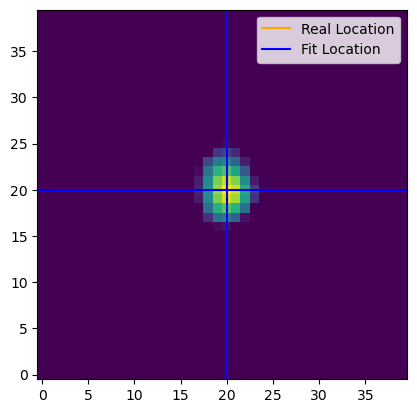

RA/DEC: 0.2804876163136214 0.02566923618724104
Az/Alt: -0.27821172263912647 0.043936886301869954

131949
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=79.9017271, x_mean=19.97622616, y_mean=19.98347852, x_stddev=1.78679246, y_stddev=1.78679246, theta=1.60549787e+12)>

    [1]: <Const2D(amplitude=199.9697344)>
Parameters:
       amplitude_0         x_mean_0      ...      theta_0          amplitude_1   
    ----------------- ------------------ ... ------------------ -----------------
    79.90172710399423 19.976226155540893 ... 1605497872727.9758 199.9697344017877


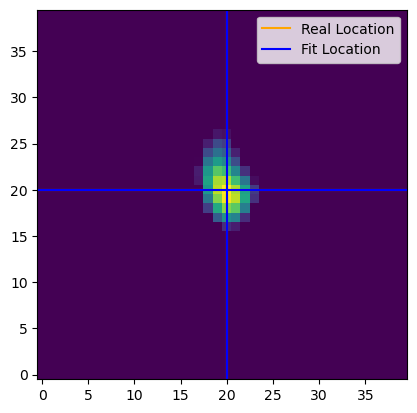

RA/DEC: 0.2163991560228169 0.04292923527827952
Az/Alt: -0.19983253684800875 0.09347979025358666

134710
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=229.15245426, x_mean=19.54001401, y_mean=20.0402576, x_stddev=2.132296, y_stddev=2.132296, theta=-7.07117369e+11)>

    [1]: <Const2D(amplitude=199.68294187)>
Parameters:
       amplitude_0          x_mean_0      ...      theta_0          amplitude_1    
    ------------------ ------------------ ... ------------------ ------------------
    229.15245426400327 19.540014010790898 ... -707117368712.6064 199.68294187404413


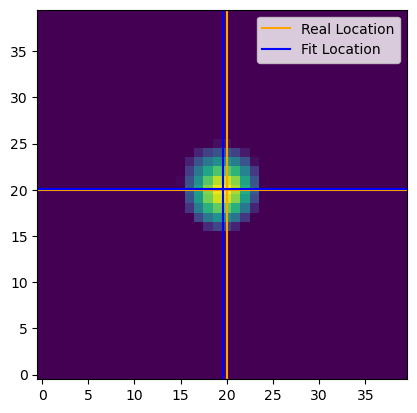

RA/DEC: -0.2626286760205403 -0.013835651305271313
Az/Alt: 0.25549707738870325 -0.06234172087113062

134712
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=210.74478284, x_mean=19.52886942, y_mean=20.02608798, x_stddev=2.05460903, y_stddev=2.05460903, theta=-1.58300206e+11)>

    [1]: <Const2D(amplitude=199.72691138)>
Parameters:
       amplitude_0          x_mean_0      ...       theta_0          amplitude_1    
    ------------------ ------------------ ... ------------------- ------------------
    210.74478283698494 19.528869416391363 ... -158300205696.24988 199.72691138075984


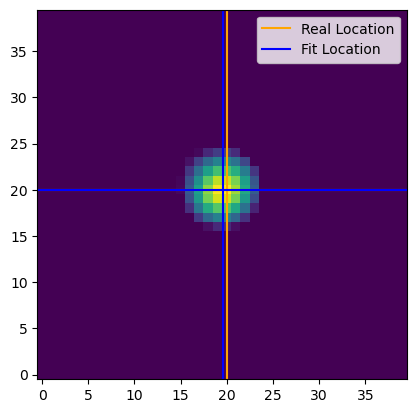

RA/DEC: -0.2748665986582637 0.00033432693453505635
Az/Alt: 0.25849105743949424 -0.09345657845370889

134714
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=160.89281443, x_mean=19.95821779, y_mean=20.0236389, x_stddev=1.90391622, y_stddev=1.90391622, theta=2.72164651e+11)>

    [1]: <Const2D(amplitude=199.81199066)>
Parameters:
       amplitude_0          x_mean_0     ...      theta_0         amplitude_1   
    ------------------ ----------------- ... ----------------- -----------------
    160.89281442809056 19.95821779371336 ... 272164651277.9841 199.8119906566017


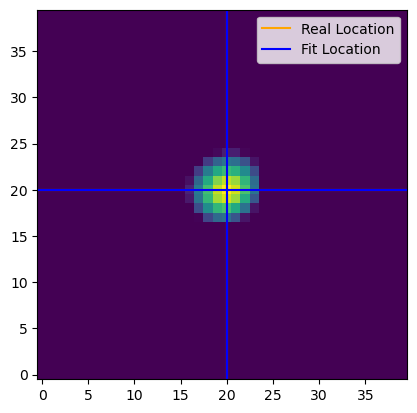

RA/DEC: 0.19662184093613178 0.002769447906757705
Az/Alt: -0.1708906465878384 0.09728414610619895

134859
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=344.34452157, x_mean=19.98126301, y_mean=20.0218226, x_stddev=2.20565839, y_stddev=2.20565839, theta=1.64129465e+12)>

    [1]: <Const2D(amplitude=199.51059242)>
Parameters:
       amplitude_0         x_mean_0      ...      theta_0          amplitude_1    
    ----------------- ------------------ ... ------------------ ------------------
    344.3445215683304 19.981263007325605 ... 1641294650948.5837 199.51059242065097


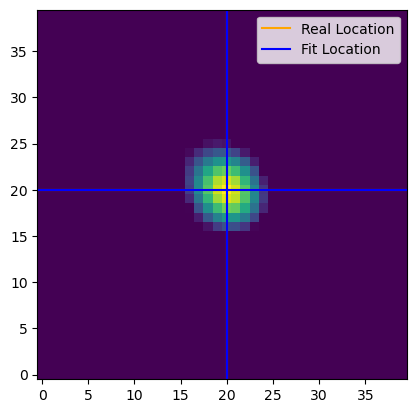

RA/DEC: 0.22192897775676101 0.004584988273563795
Az/Alt: -0.20613171361211946 0.08236024483305525

134861
Model: CompoundModel
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian2D(amplitude=378.17955207, x_mean=19.93298011, y_mean=20.02026764, x_stddev=2.17787358, y_stddev=2.17787358, theta=4.91793169e+11)>

    [1]: <Const2D(amplitude=199.49472295)>
Parameters:
       amplitude_0          x_mean_0      ...      theta_0         amplitude_1    
    ------------------ ------------------ ... ----------------- ------------------
    378.17955207333205 19.932980110854494 ... 491793168699.2731 199.49472294978077


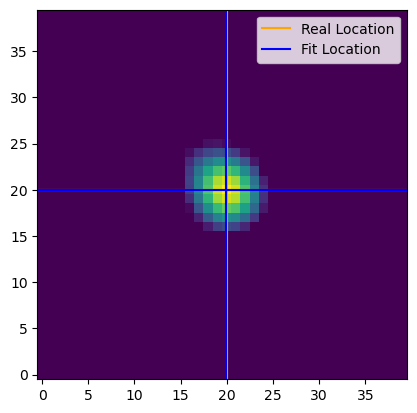

RA/DEC: 0.16890723467804492 0.006141538426163606
Az/Alt: -0.1438341314678154 0.08876437937440544



In [6]:
# computed with CW rotation offset
path = './testing_files_5/redu02/'#../pointing_maps/cleaned_maps/'#'./testing_files/'#'../pointing_maps/cleaned_maps/'
obs_names = [131947,131949,134710,134712,134714,134859,134861]
simbad_results = Simbad.query_object('VLA 1623')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
nc_files = os.listdir('./nc_files')
for obs in obs_names:
    print(obs)
    path_obj = path + str(obs) + '/raw/'
    fits_file_ = fits.open(path_obj + f'toltec_commissioning_a1100_science_{str(obs)}_citlali.fits')
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    nc_file_path = [file for file in nc_files if str(obs) in file][0]
    nc_file = Dataset('./nc_files/' + nc_file_path)
    Tel_PA = nc_file.variables['Data.TelescopeBackend.ActParAng'][:].data # in radians
    Tel_PA = np.median(Tel_PA)
    coord_pix = WCS(map_header,naxis=2).world_to_pixel(real_coordinate)
    cut_map = np.clip(map_dat, a_min=200, a_max=1000)
    map_x, map_y = locate_pointsource(cut_map, coord_pix[0], coord_pix[1],vis=True)
    map_coordinate = WCS(map_header,naxis=2).pixel_to_world(map_x, map_y).icrs # in ICRS
    delta_ra = map_coordinate.ra.arcsec - real_coordinate.ra.arcsec
    delta_dec = map_coordinate.dec.arcsec - real_coordinate.dec.arcsec
    delta_az, delta_alt = rot_a(Tel_PA) @ np.array([-delta_ra, delta_dec])
    print('RA/DEC:', -delta_ra, -delta_dec)
    print('Az/Alt:', -delta_az, -delta_alt)
    print('')

In [7]:
real_coordinate

<SkyCoord (ICRS): (ra, dec) in deg
    (246.61008333, -24.40833333)>

### Compare Coadds

VLA 1623
-92.79760073894722
944.0552639025713
Calibration
Offset peak flux: 944
-26.942565575192923
299.41826987320144
No Offset peak flux: 299
-24.69167245041833
298.81448397543426
CCW peak flux: 299
-23.69405707035153
300.20890511303986
CW peak flux: 300


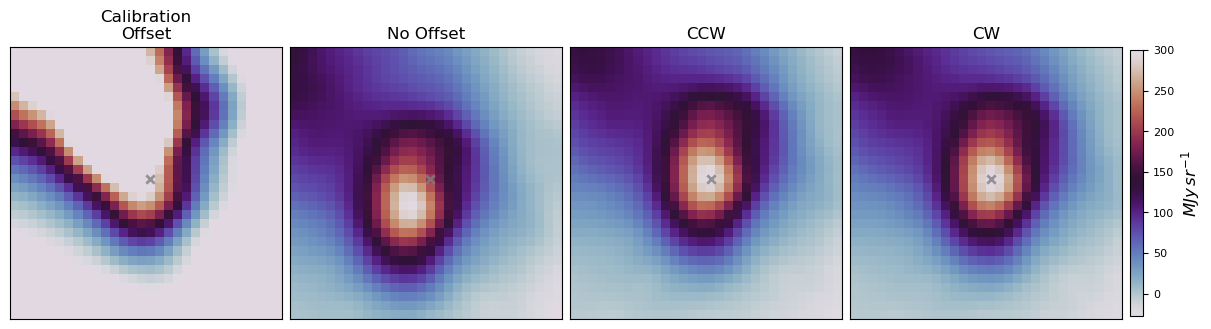

[CHG85] GSS 30 IRS 3
-29.678570643905452
214.8593307875666
Calibration
Offset peak flux: 215
-15.170294827084785
52.03825244500137
No Offset peak flux: 52
-15.443830712595863
52.24379195140605
CCW peak flux: 52
-15.975606896378691
53.053503940957164
CW peak flux: 53


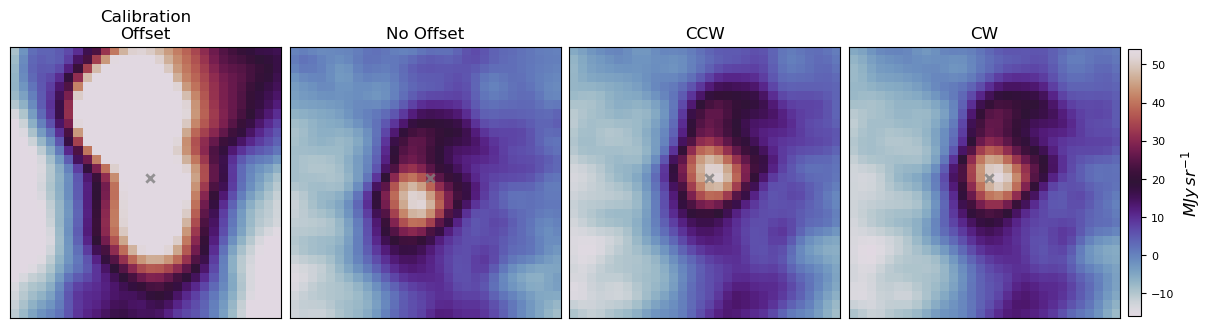

[GY92] 21
-124.61865058759884
66.43690776398029
Calibration
Offset peak flux: 66
-40.30429596769166
16.96324177584003
No Offset peak flux: 17
-40.06683326225019
16.632520227178876
CCW peak flux: 17
-40.11274170094991
16.661708698649843
CW peak flux: 17


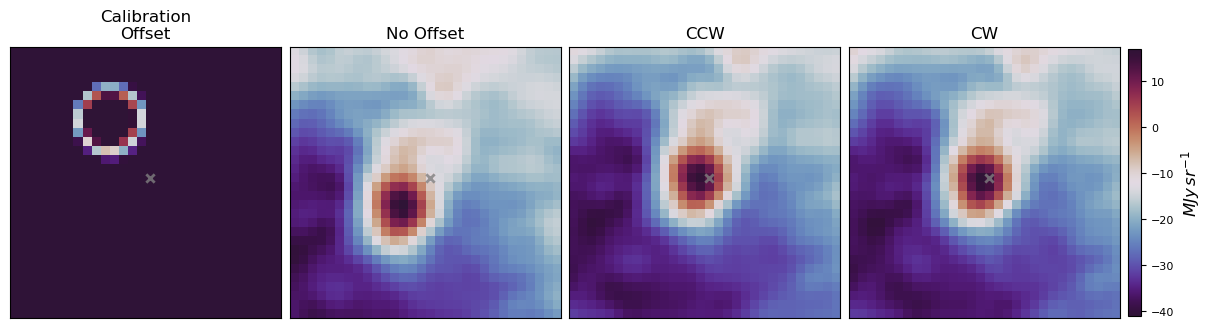

In [8]:
# computed with CW rotation offset
path_cal = './cal_offset/toltec_commissioning_a1100_citlali.fits'#'../fits_files/new/signal_comp_2/toltec_commissioning_a1100_citlali.fits'
path_0 = './testing_files_3/redu00/131947/raw/toltec_commissioning_a1100_science_131947_citlali.fits'
path_ccw = './testing_files_4/redu01/131947/raw/toltec_commissioning_a1100_science_131947_citlali.fits'
path_cw = './testing_files_5/redu02/131947/raw/toltec_commissioning_a1100_science_131947_citlali.fits'
paths = [path_cal, path_0, path_ccw, path_cw]
titles = ['Calibration\nOffset', 'No Offset', 'CCW', 'CW']
ps = 30
print('VLA 1623')
simbad_results = Simbad.query_object('VLA 1623')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
fig, axs = plt.subplots(1,4,figsize=(12,6),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
for i,file in enumerate(paths):
    fits_file_ = fits.open(file)
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    viswcs = WCS(map_header,naxis=2)
    coord_pix = viswcs.world_to_pixel(real_coordinate)
    x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
    map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
    print(map_dat.min())
    print(map_dat.max())
    norm = simple_norm(map_dat, vmin=-28,vmax=300)
    im = axs[i].imshow(map_dat,origin='lower',norm=norm,cmap='twilight')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8)
    axs[i].set_title(titles[i])
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    print(titles[i] + ' peak flux: ' + str(round(np.max(map_dat))))
cbar = fig.colorbar(im, ax=axs[-1], orientation='vertical', shrink=0.45, pad=0.03)
name = r'$MJy\,sr^{-1}$'
cbar.set_label(name, labelpad=3, fontsize=12)
cbar.ax.tick_params(labelsize=8)
plt.show()
print('[CHG85] GSS 30 IRS 3')
simbad_results = Simbad.query_object('[CHG85] GSS 30 IRS 3')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
fig, axs = plt.subplots(1,4,figsize=(12,6),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
for i,file in enumerate(paths):
    fits_file_ = fits.open(file)
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    viswcs = WCS(map_header,naxis=2)
    coord_pix = viswcs.world_to_pixel(real_coordinate)
    x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
    map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
    print(map_dat.min())
    print(map_dat.max())
    norm = simple_norm(map_dat, vmin=-16,vmax=54)
    im = axs[i].imshow(map_dat,origin='lower',norm=norm,cmap='twilight')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8)
    axs[i].set_title(titles[i])
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    print(titles[i] + ' peak flux: ' + str(round(np.max(map_dat))))
cbar = fig.colorbar(im, ax=axs[-1], orientation='vertical', shrink=0.45, pad=0.03)
name = r'$MJy\,sr^{-1}$'
cbar.set_label(name, labelpad=3, fontsize=12)
cbar.ax.tick_params(labelsize=8)
plt.show()
print('[GY92] 21')
simbad_results = Simbad.query_object('[GY92] 21')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
fig, axs = plt.subplots(1,4,figsize=(12,6),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
for i,file in enumerate(paths):
    fits_file_ = fits.open(file)
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    viswcs = WCS(map_header,naxis=2)
    coord_pix = viswcs.world_to_pixel(real_coordinate)
    x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
    map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
    print(map_dat.min())
    print(map_dat.max())
    norm = simple_norm(map_dat, vmin=-41,vmax=17)
    im = axs[i].imshow(map_dat,origin='lower',norm=norm,cmap='twilight_shifted')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8)
    axs[i].set_title(titles[i])
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    print(titles[i] + ' peak flux: ' + str(round(np.max(map_dat))))
cbar = fig.colorbar(im, ax=axs[-1], orientation='vertical', shrink=0.45, pad=0.03)
name = r'$MJy\,sr^{-1}$'
cbar.set_label(name, labelpad=3, fontsize=12)
cbar.ax.tick_params(labelsize=8)
plt.show()

In [9]:
for obs in obs_names:
    path_cw = f'./testing_files_5/redu02/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'
    print(fits.open(path_cw)[0].header['EXPTIME']/60)

20.4414976000785
20.542668799559333
20.447641599178333
20.49228800137833
20.503756801287334
20.491741867860167
20.508535468578334


In [10]:
obs_names

[131947, 131949, 134710, 134712, 134714, 134859, 134861]

VLA 1623
Coadded
Calibration
Offset peak flux: 944
Coadded
Coadded
Coadded
131947
Calibration
Offset peak flux: 301
131947
131947
131947
131949
Calibration
Offset peak flux: 278
131949
131949
131949
134710
Calibration
Offset peak flux: 412
134710
134710
134710
134712
Calibration
Offset peak flux: 390
134712
134712
134712
134714
Calibration
Offset peak flux: 339
134714
134714
134714
134859
Calibration
Offset peak flux: 513
134859
134859
134859
134861
Calibration
Offset peak flux: 536
134861
134861
134861


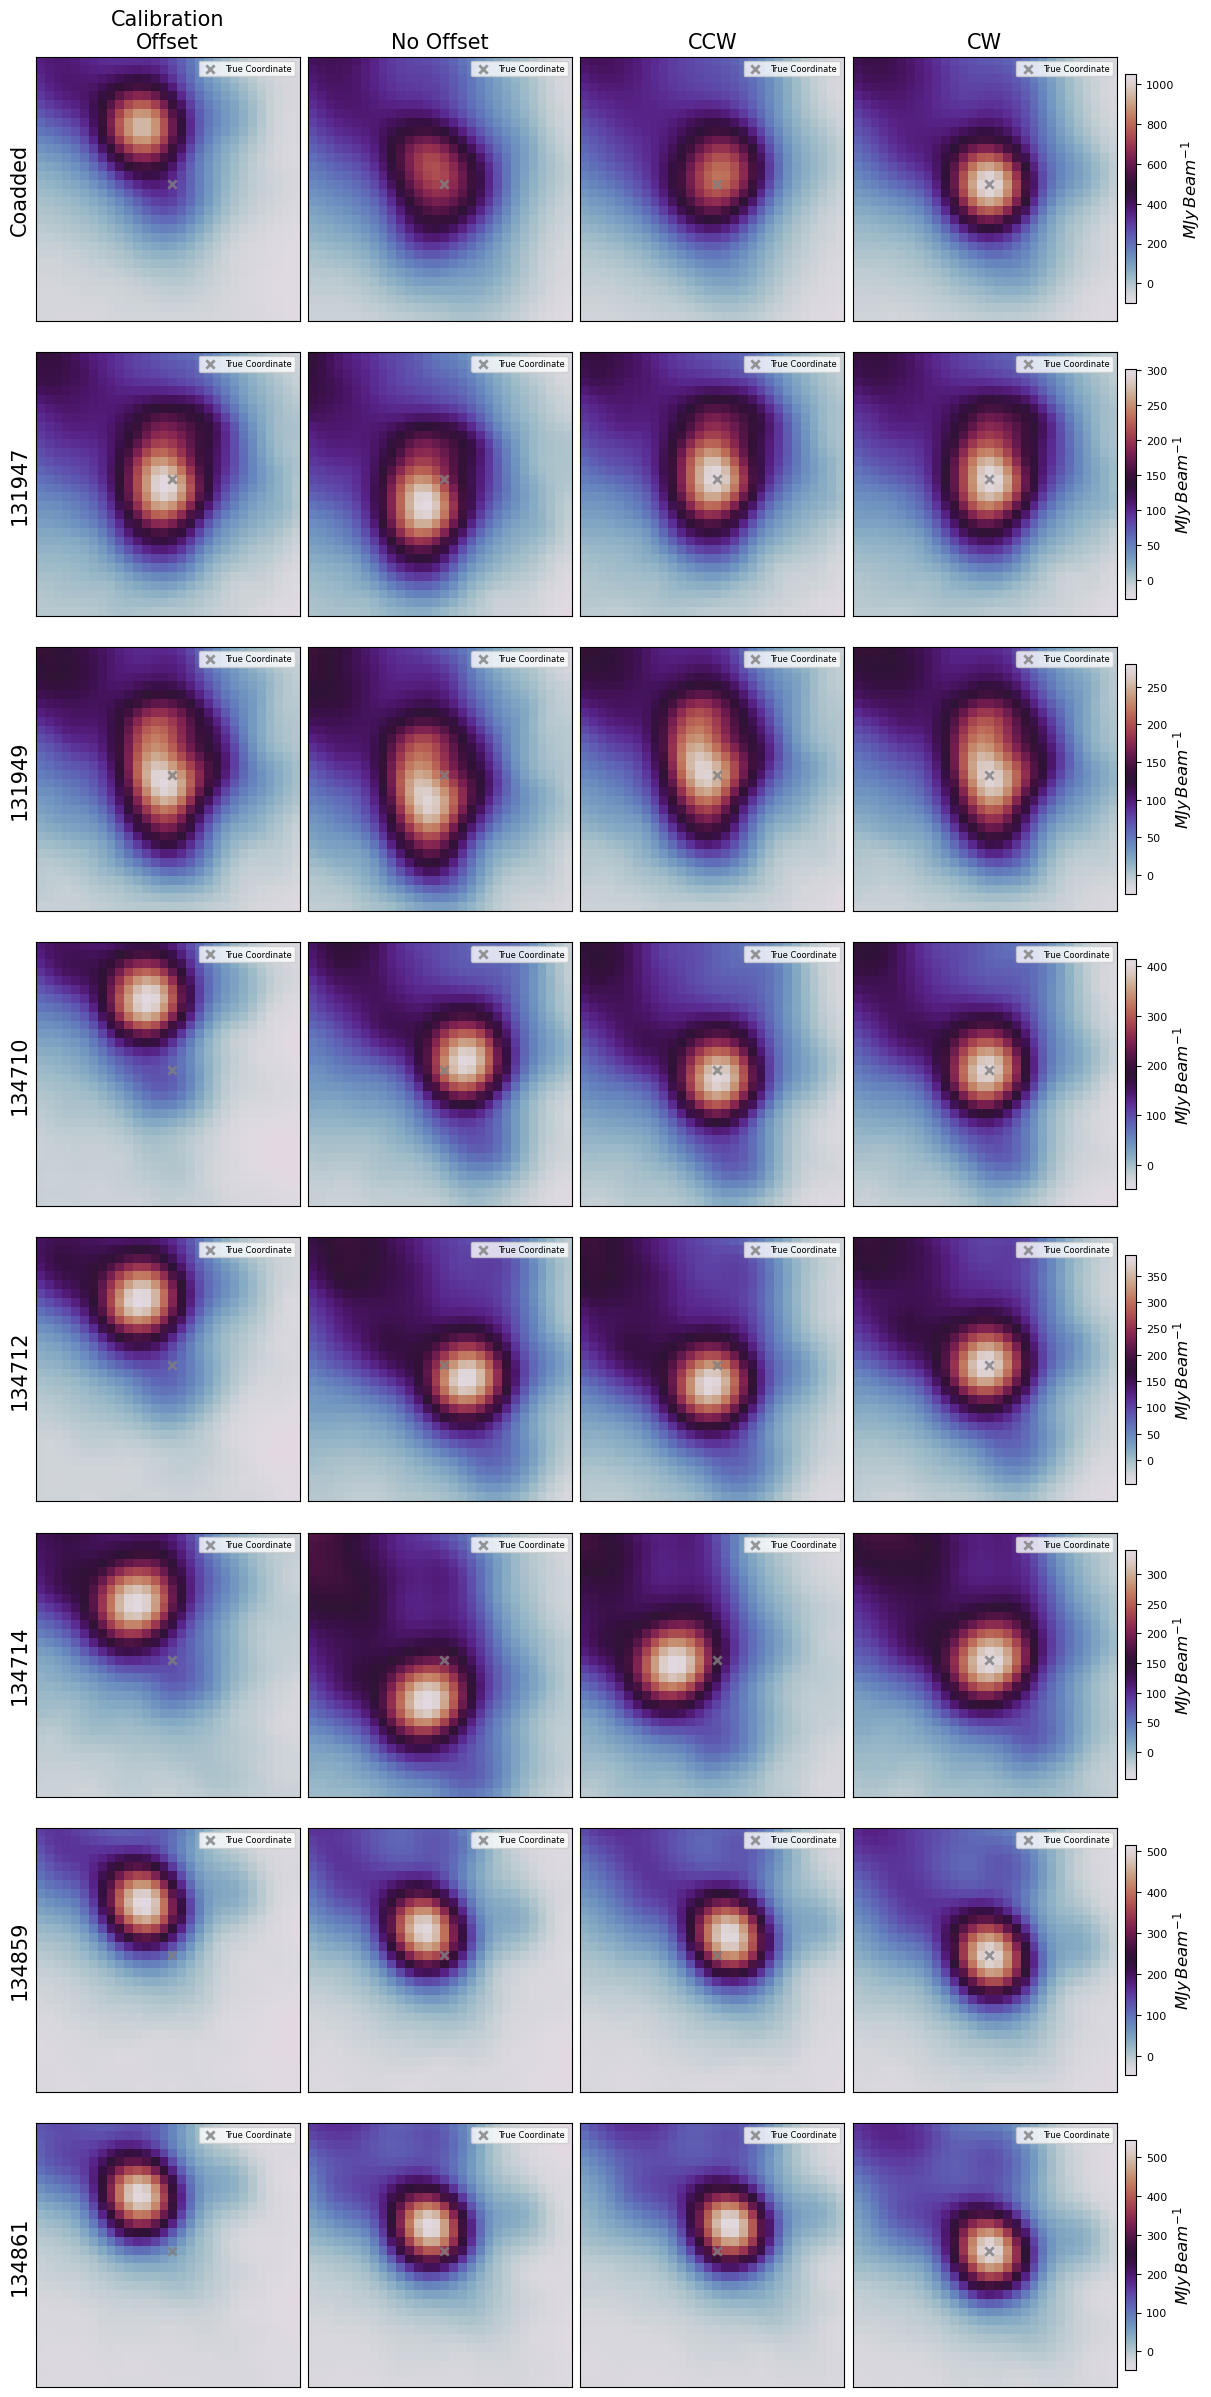

In [11]:
# computed with CW rotation offset
titles = ['Calibration\nOffset', 'No Offset', 'CCW', 'CW']
ps = 30
print('VLA 1623')
simbad_results = Simbad.query_object('VLA 1623')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
fig, axs = plt.subplots(8,4,figsize=(12,24),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
obs_names = ['Coadded', 131947, 131949, 134710, 134712, 134714, 134859, 134861]
minmaxes = [(-100,1050),(-27,301),(-25,280),(-48,413),(-46,390),(-46,341),(-45,514),(-47,543)]
maxes = []
mins = []
for i, obsmaxes in enumerate(zip(obs_names, minmaxes)):
    obs = obsmaxes[0]
    minmax = obsmaxes[1]
    if obs == 'Coadded':
        path_cal = f'./testing_files_og/redu03/{obs}/raw/toltec_commissioning_a1100_citlali.fits'#./cal_offset/toltec_commissioning_a1100_citlali.fits'#'../fits_files/new/signal_comp_2/toltec_commissioning_a1100_citlali.fits'
        path_0 = f'./testing_files_3/redu00/{obs}/raw/toltec_commissioning_a1100_citlali.fits'
        path_ccw = f'./testing_files_4/redu01/{obs}/raw/toltec_commissioning_a1100_citlali.fits'
        path_cw = f'./testing_files_5/redu02/{obs}/raw/toltec_commissioning_a1100_citlali.fits'
    else:
        path_cal = f'./testing_files_og/redu03/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'#./cal_offset/toltec_commissioning_a1100_citlali.fits'#'../fits_files/new/signal_comp_2/toltec_commissioning_a1100_citlali.fits'
        path_0 = f'./testing_files_3/redu00/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'
        path_ccw = f'./testing_files_4/redu01/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'
        path_cw = f'./testing_files_5/redu02/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'
    paths = [path_cal, path_0, path_ccw, path_cw]
    max_ = []
    min_ = []
    for j,file in enumerate(paths):
        fits_file_ = fits.open(file)
        map_dat = fits_file_[6].data[0][0]
        map_header = fits_file_[6].header
        viswcs = WCS(map_header,naxis=2)
        coord_pix = viswcs.world_to_pixel(real_coordinate)
        x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
        map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
        # print(map_dat.min())
        # print(map_dat.max())
        norm = simple_norm(map_dat, vmin=minmax[0],vmax=minmax[1])
        im = axs[i,j].imshow(map_dat,origin='lower',norm=norm,cmap='twilight')
        axs[i,j].grid(True, linestyle='--', alpha=0.6)
        axs[i,j].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8,label='True Coordinate')
        axs[i,j].legend(fontsize=6)
        axs[0,j].set_title(titles[j],fontsize=15)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        print(obs)
        if j == 0:
            print(titles[j] + ' peak flux: ' + str(round(np.max(map_dat))))
        max_.append(np.max(map_dat))
        min_.append(np.min(map_dat))
    axs[i,0].set_ylabel(obs,fontsize=15)
    cbar = fig.colorbar(im, ax=axs[i,-1], orientation='vertical', shrink=0.8, pad=0.03)
    name = r'$MJy\,Beam^{-1}$'
    cbar.set_label(name, labelpad=3, fontsize=12)
    cbar.ax.tick_params(labelsize=8)
    maxes.append(max_)
    mins.append(min_)
plt.show()


VLA 1623


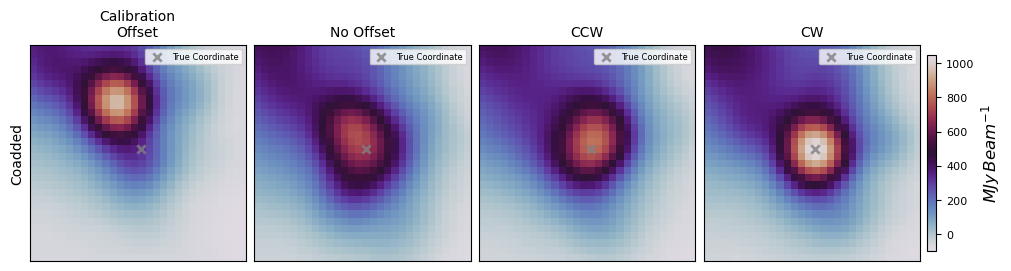

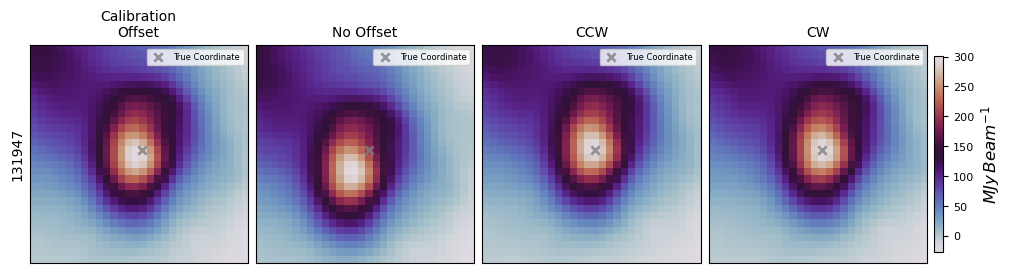

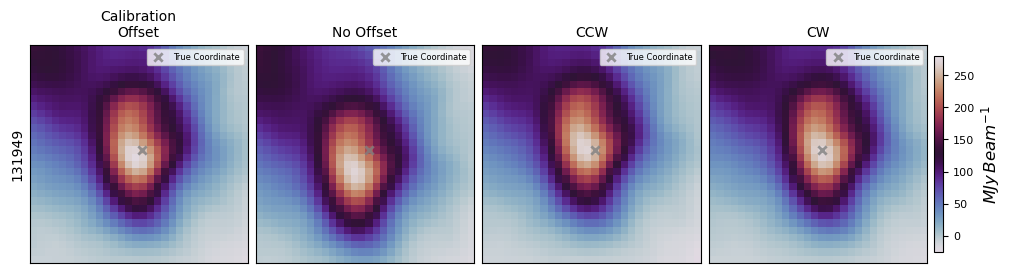

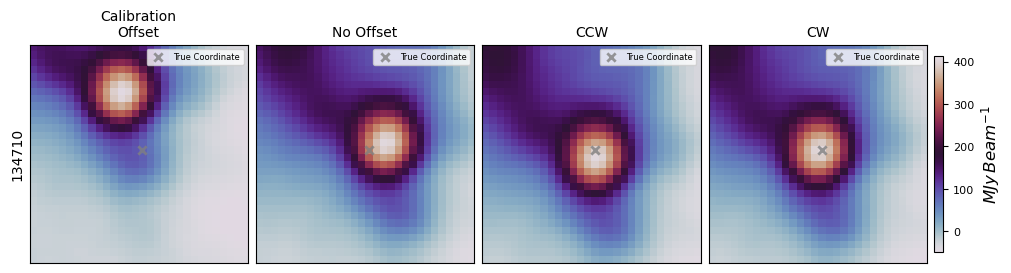

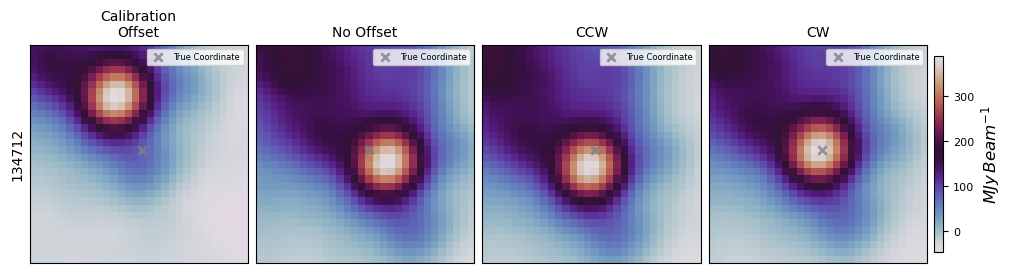

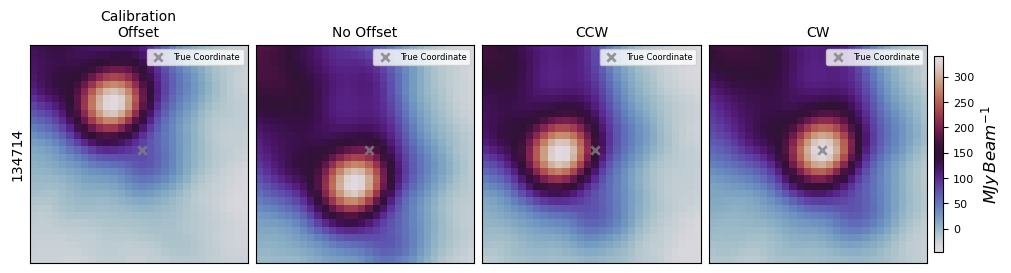

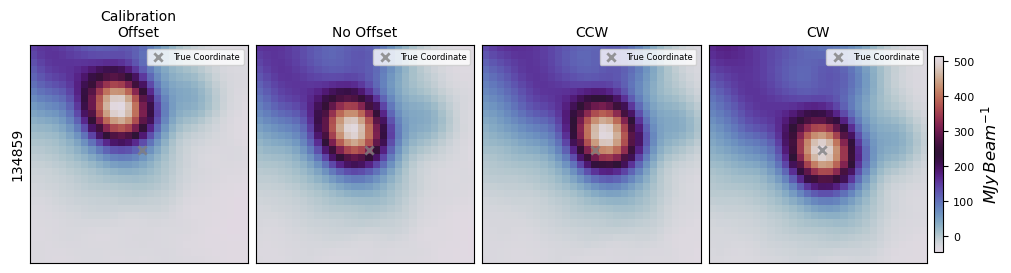

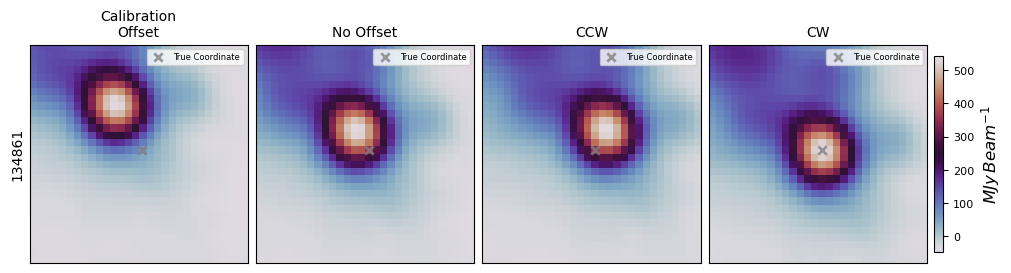

In [12]:
# computed with CW rotation offset
titles = ['Calibration\nOffset', 'No Offset', 'CCW', 'CW']
ps = 30
print('VLA 1623')
simbad_results = Simbad.query_object('VLA 1623')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
obs_names = ['Coadded', 131947, 131949, 134710, 134712, 134714, 134859, 134861]
minmaxes = [(-100,1050),(-27,301),(-25,280),(-48,413),(-46,390),(-46,341),(-45,514),(-47,543)]
maxes = []
mins = []
for i, obsmaxes in enumerate(zip(obs_names, minmaxes)):
    fig, axs = plt.subplots(1,4,figsize=(10,4),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
    obs = obsmaxes[0]
    minmax = obsmaxes[1]
    if obs == 'Coadded':
        path_cal = f'./testing_files_og/redu03/{obs}/raw/toltec_commissioning_a1100_citlali.fits'#./cal_offset/toltec_commissioning_a1100_citlali.fits'#'../fits_files/new/signal_comp_2/toltec_commissioning_a1100_citlali.fits'
        path_0 = f'./testing_files_3/redu00/{obs}/raw/toltec_commissioning_a1100_citlali.fits'
        path_ccw = f'./testing_files_4/redu01/{obs}/raw/toltec_commissioning_a1100_citlali.fits'
        path_cw = f'./testing_files_5/redu02/{obs}/raw/toltec_commissioning_a1100_citlali.fits'
    else:
        path_cal = f'./testing_files_og/redu03/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'#./cal_offset/toltec_commissioning_a1100_citlali.fits'#'../fits_files/new/signal_comp_2/toltec_commissioning_a1100_citlali.fits'
        path_0 = f'./testing_files_3/redu00/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'
        path_ccw = f'./testing_files_4/redu01/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'
        path_cw = f'./testing_files_5/redu02/{obs}/raw/toltec_commissioning_a1100_science_{obs}_citlali.fits'
    paths = [path_cal, path_0, path_ccw, path_cw]
    max_ = []
    min_ = []
    for j,file in enumerate(paths):
        fits_file_ = fits.open(file)
        map_dat = fits_file_[6].data[0][0]
        map_header = fits_file_[6].header
        viswcs = WCS(map_header,naxis=2)
        coord_pix = viswcs.world_to_pixel(real_coordinate)
        x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
        map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
        # print(map_dat.min())
        # print(map_dat.max())
        norm = simple_norm(map_dat, vmin=minmax[0],vmax=minmax[1])
        im = axs[j].imshow(map_dat,origin='lower',norm=norm,cmap='twilight')
        axs[j].grid(True, linestyle='--', alpha=0.6)
        axs[j].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8,label='True Coordinate')
        axs[j].legend(fontsize=6)
        axs[j].set_title(titles[j],fontsize=10)
        axs[j].set_xticks([])
        axs[j].set_yticks([])
        #print(titles[j] + ' peak flux: ' + str(round(np.max(map_dat))))
        max_.append(np.max(map_dat))
        min_.append(np.min(map_dat))
    axs[0].set_ylabel(obs,fontsize=10)
    cbar = fig.colorbar(im, ax=axs[-1], orientation='vertical', shrink=0.5, pad=0.03)
    name = r'$MJy\,Beam^{-1}$'
    cbar.set_label(name, labelpad=3, fontsize=12)
    cbar.ax.tick_params(labelsize=8) 
    maxes.append(max_)
    mins.append(min_)
    plt.show()


In [13]:
path_cal = './cal_offset/toltec_commissioning_a1100_citlali.fits'#'../fits_files/new/signal_comp_2/toltec_commissioning_a1100_citlali.fits'
fits.open(path_cal)[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2025-07-17T20:05:34' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
HIERARCH TO_MJY/BEAM =       1 / Conversion to mJy/beam                         
HIERARCH TO_MJY/SR = 1.01621618883213 / Conversion to MJy/sr                    
TO_UK   = 6.19187189190542E-06 / Conversion to uK                               
HIERARCH TO_JY/PIXEL = 2.38855828231115E-05 / Conversion to Jy/pixel            
OBSNUM0 = '131947  '           / Observation Number 0                           
OBSNUM1 = '131949  '        

### Compare Maps

VLA 1623
Calibration
Offset peak flux: 944
No Offset peak flux: 751
CCW peak flux: 820
CW peak flux: 1050


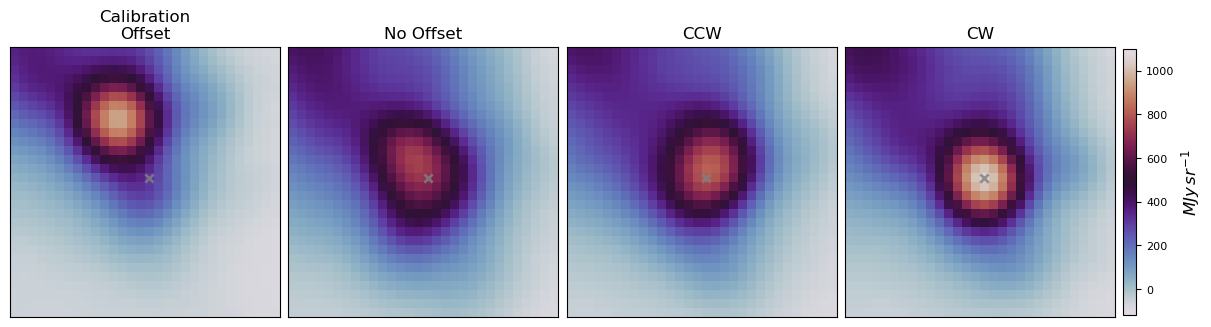

[CHG85] GSS 30 IRS 3
Calibration
Offset peak flux: 215
No Offset peak flux: 152
CCW peak flux: 178
CW peak flux: 233


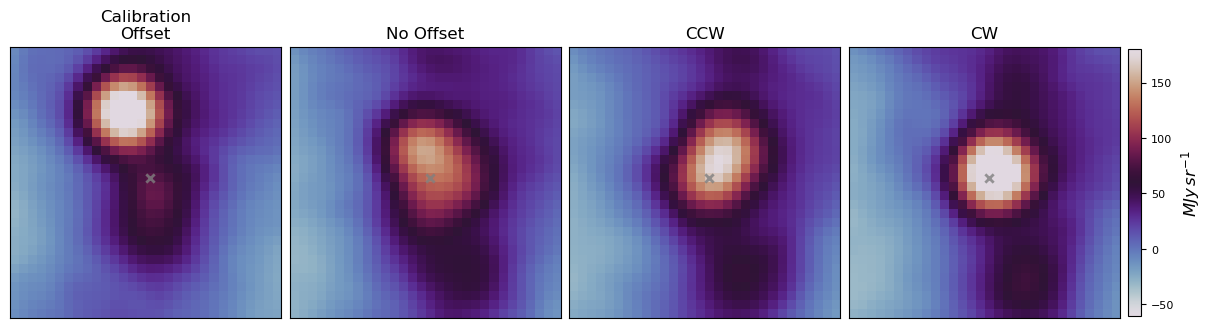

[GY92] 21
Calibration
Offset peak flux: 66
No Offset peak flux: 12
CCW peak flux: 38
CW peak flux: 88


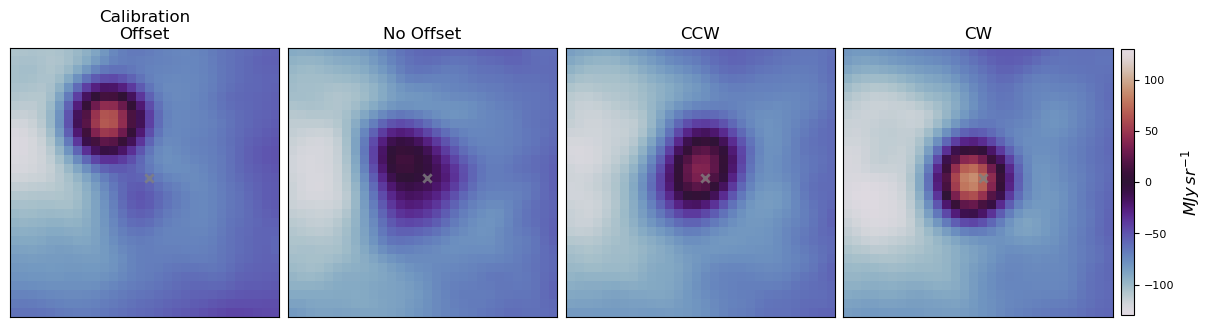

In [14]:
# computed with CW rotation offset
path_cal = './cal_offset/toltec_commissioning_a1100_citlali.fits'#'../fits_files/new/signal_comp_2/toltec_commissioning_a1100_citlali.fits'
path_0 = './testing_files_3/redu00/coadded/raw/toltec_commissioning_a1100_citlali.fits'
path_ccw = './testing_files_4/redu01/coadded/raw/toltec_commissioning_a1100_citlali.fits'
path_cw = './testing_files_5/redu02/coadded/raw/toltec_commissioning_a1100_citlali.fits'
paths = [path_cal, path_0, path_ccw, path_cw]
titles = ['Calibration\nOffset', 'No Offset', 'CCW', 'CW']
ps = 30
print('VLA 1623')
simbad_results = Simbad.query_object('VLA 1623')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
fig, axs = plt.subplots(1,4,figsize=(12,6),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
for i,file in enumerate(paths):
    fits_file_ = fits.open(file)
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    viswcs = WCS(map_header,naxis=2)
    coord_pix = viswcs.world_to_pixel(real_coordinate)
    x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
    map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
    norm = simple_norm(map_dat, vmin=-120,vmax=1100)
    im = axs[i].imshow(map_dat,origin='lower',norm=norm,cmap='twilight')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8)
    axs[i].set_title(titles[i])
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    print(titles[i] + ' peak flux: ' + str(round(np.max(map_dat))))
cbar = fig.colorbar(im, ax=axs[-1], orientation='vertical', shrink=0.45, pad=0.03)
name = r'$MJy\,sr^{-1}$'
cbar.set_label(name, labelpad=3, fontsize=12)
cbar.ax.tick_params(labelsize=8)
plt.show()
print('[CHG85] GSS 30 IRS 3')
simbad_results = Simbad.query_object('[CHG85] GSS 30 IRS 3')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
fig, axs = plt.subplots(1,4,figsize=(12,6),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
for i,file in enumerate(paths):
    fits_file_ = fits.open(file)
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    viswcs = WCS(map_header,naxis=2)
    coord_pix = viswcs.world_to_pixel(real_coordinate)
    x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
    map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
    norm = simple_norm(map_dat, vmin=-60,vmax=180)
    im = axs[i].imshow(map_dat,origin='lower',norm=norm,cmap='twilight')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8)
    axs[i].set_title(titles[i])
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    print(titles[i] + ' peak flux: ' + str(round(np.max(map_dat))))
cbar = fig.colorbar(im, ax=axs[-1], orientation='vertical', shrink=0.45, pad=0.03)
name = r'$MJy\,sr^{-1}$'
cbar.set_label(name, labelpad=3, fontsize=12)
cbar.ax.tick_params(labelsize=8)
plt.show()
print('[GY92] 21')
simbad_results = Simbad.query_object('[GY92] 21')
RA, DEC = simbad_results.to_pandas()[['ra','dec']].values[0]
real_coordinate = SkyCoord(ra=RA, dec=DEC, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
fig, axs = plt.subplots(1,4,figsize=(12,6),sharex=True,sharey=True,constrained_layout=True)#,subplot_kw=dict(projection=viswcs))
for i,file in enumerate(paths):
    fits_file_ = fits.open(file)
    map_dat = fits_file_[6].data[0][0]
    map_header = fits_file_[6].header
    viswcs = WCS(map_header,naxis=2)
    coord_pix = viswcs.world_to_pixel(real_coordinate)
    x0_f, y0_f = int(np.round(coord_pix[0])), int(np.round(coord_pix[1]))
    map_dat = map_dat[y0_f-ps//2:y0_f+ps//2,x0_f-ps//2:x0_f+ps//2]
    norm = simple_norm(map_dat, vmin=-130,vmax=130)
    im = axs[i].imshow(map_dat,origin='lower',norm=norm,cmap='twilight')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].scatter(x=ps//2,y=ps//2,marker='x',linewidth=2,color='grey',alpha=0.8)
    axs[i].set_title(titles[i])
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    print(titles[i] + ' peak flux: ' + str(round(np.max(map_dat))))
cbar = fig.colorbar(im, ax=axs[-1], orientation='vertical', shrink=0.45, pad=0.03)
name = r'$MJy\,sr^{-1}$'
cbar.set_label(name, labelpad=3, fontsize=12)
cbar.ax.tick_params(labelsize=8)
plt.show()

In [15]:
coord = SkyCoord(ra=246.5981847, dec=-24.4110249, frame='icrs', obstime="J2000", unit=(u.deg,u.deg))
Simbad.query_region(coord,radius=8*u.arcsec)

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode
,deg,deg,mas,mas,deg,,
object,float64,float64,float32,float32,int16,str1,object
[GY92] 21,246.59824899999998,-24.410971,80.0,70.0,87,N,2003yCat.2246....0C
[LLL2015] Sa4,246.59862500000003,-24.411055555555556,--,--,--,S,2015A&A...578A.131L


## Put into table

In [16]:
from astropy.table import QTable
import numpy as np
from astropy.io import ascii
import io

In [ ]:
offsets_az = [2.59, 2.58, -2.83, -2.18, 3.97, 1.18, 0.19]
offsets_el = [2.66, 2.11, -0.53, 2.44, 2.97, -3.53, -3.22]
obs_names = [131947, 131949, 134710, 134712, 134714, 134859, 134861]
best_offsets = QTable(data=np.array([obs_names,offsets_az,offsets_el]).T, names=['Observation', 'Az Offset', 'El Offset'], dtype=[int,float,float])
output_stream = io.StringIO()
ascii.write(best_offsets, './pointing_table', format='latex')
latex_string = output_stream.getvalue()

OSError: File ./pointing_table already exists. If you mean to replace it then use the argument "overwrite=True".

In [ ]:
output_stream